# PASO 1: CARGA Y FILTRADO BIG DATA CON DASK

In [55]:
# PASO 1: CARGA Y FILTRADO BIG DATA CON DASK

import dask.dataframe as dd
import pandas as pd

print("🚀 Iniciando motor de procesamiento paralelo Dask...")

# 1. Carga "Perezosa" (Lazy Evaluation)
# Dask NO satura la RAM. Lee el esquema del archivo gigante y crea un grafo de tareas.
# Usamos dtype=str para evitar que colapse adivinando tipos en millones de filas.
df_espana_dask = dd.read_csv('../data/raw/spanish_houses.csv', dtype=str)

# 2. Filtrado y Selección de Columnas en Paralelo
# Le decimos a Dask qué queremos, pero aún no realiza el cálculo.
df_sevilla_dask = df_espana_dask[df_espana_dask['loc_zone'].str.contains('sevilla', case=False, na=False)]

columnas_modelo = [
    'price', 'm2_real', 'room_num', 'bath_num', 'loc_city', 'loc_district',
    'house_type', 'balcony', 'garage', 'swimming_pool', 'terrace', 'storage_room', 
    'lift', 'garden', 'condition'
]
df_modelo_dask = df_sevilla_dask[columnas_modelo]

# 3. EJECUCIÓN (The Compute Step)
# Ahora sí, Dask usa todos los núcleos de la CPU para buscar en el archivo gigante,
# extrae solo las casas de Sevilla y nos lo devuelve como un DataFrame de Pandas normal.
print("⏳ Filtrando el archivo masivo en múltiples núcleos (Out-of-core computation)...")
df_modelo = df_modelo_dask.compute(scheduler='threads')

# Volvemos a convertir el índice para que empiece en 0
df_modelo = df_modelo.reset_index(drop=True)

print(f"✅ ¡Éxito! Viviendas extraídas a la memoria local: {df_modelo.shape[0]}")
display(df_modelo.head())

🚀 Iniciando motor de procesamiento paralelo Dask...
⏳ Filtrando el archivo masivo en múltiples núcleos (Out-of-core computation)...
✅ ¡Éxito! Viviendas extraídas a la memoria local: 5076


,price,m2_real,room_num,bath_num,loc_city,loc_district,house_type,balcony,garage,swimming_pool,terrace,storage_room,lift,garden,condition
0,212000,302,5,3,Guillena,<NA>,Chalet pareado,0,plaza de garaje incluida en el precio,1,1,0,<NA>,1,<NA>
1,280000,500,5,3,Almadén de la Plata,"Calle las Granadinas, 20",Casa o chalet independiente,1,plaza de garaje incluida en el precio,1,1,1,<NA>,0,segunda mano/buen estado
2,50000,200,2,1,El Pedroso,"Calle Yesca, 7",Casa de pueblo,0,<NA>,0,0,0,<NA>,0,segunda mano/para reformar
3,90000,200,3,1,Guadalcanal,"Calle Vicente Amigo, 42",Casa de pueblo,1,plaza de garaje incluida en el precio,0,0,1,<NA>,0,segunda mano/buen estado
4,125000,120,4,3,Castilblanco de los Arroyos,"Calle Valdes Leal, 8",Piso,1,<NA>,0,1,0,0,0,segunda mano/buen estado


# PASO 2: LIMPIEZA Y PREPARACIÓN DE DATOS

In [56]:
# PASO 2: LIMPIEZA Y PREPARACIÓN DE DATOS (VERSIÓN CORREGIDA)

df_modelo['room_num'] = df_modelo['room_num'].astype(str).replace('sin habitación', '0')
df_modelo['bath_num'] = df_modelo['bath_num'].astype(str).replace('sin baños', '0')

# 2. Forzamos el formato numérico 
columnas_numericas = ['price', 'm2_real', 'room_num', 'bath_num']
for col in columnas_numericas:
    # Primero limpiamos las comas en un texto temporal
    texto_limpio = df_modelo[col].astype(str).str.replace(',', '.')
    # Extraemos solo los números
    solo_numeros = texto_limpio.str.extract(r'(\d+\.?\d*)')[0]
    # Sobrescribimos la columna entera cambiándole el tipo de dato a numérico
    df_modelo[col] = pd.to_numeric(solo_numeros, errors='coerce')

# 3. Borramos los pisos que se han quedado sin Precio o Metros 
df_modelo = df_modelo.dropna(subset=['price', 'm2_real'])

# Mapeo (Creamos nueva variable operando elemento a elemento)
df_modelo['price_m2'] = df_modelo['price'] / df_modelo['m2_real']

# Unificar tipos de vivienda
df_modelo['house_type'] = df_modelo['house_type'].str.strip()
df_modelo['house_type'] = df_modelo['house_type'].replace({
    'Casa o chalet independiente': 'Casa o chalet',
    'Chalet pareado': 'Chalet',
    'Chalet adosado': 'Chalet',
    'Casa de pueblo': 'Casa',
    'Casa rural': 'Casa',
    'Casa terrera': 'Casa',
    'Torre': 'Piso',
})

# Ordenación (Organizamos del piso más caro al más barato)
df_modelo = df_modelo.sort_values(by='price', ascending=False)

print(f"Limpieza terminada. Nos quedan {df_modelo.shape[0]} casas en perfecto estado.")
print("Vistazo a las columnas numéricas clave:")
display(df_modelo[['price', 'm2_real', 'price_m2', 'room_num', 'bath_num']].head())

Limpieza terminada. Nos quedan 5076 casas en perfecto estado.
Vistazo a las columnas numéricas clave:


,price,m2_real,price_m2,room_num,bath_num
3796,6273680,10391,6.037609e+02,1,1
2798,6000000,19882,3.017805e+02,6,4
972,3834000,426000,9.000000e+00,8,6
2395,3200000,2000,1.600000e+03,4,4
1066,3000000,2,1.500000e+06,8,6


# PASO 3: ELIMINACIÓN DE OUTLIERS

In [57]:
# PASO 3: ELIMINACIÓN DE OUTLIERS (VALORES ATÍPICOS)

print(f"Casas antes de limpiar rarezas: {df_modelo.shape[0]}")

# 1. Filtro de Precios: Casas entre 30.000€ y 2.000.000€
df_modelo = df_modelo[(df_modelo['price'] >= 30000) & (df_modelo['price'] <= 2000000)]

# 2. Filtro de m2: Desde un micro-estudio (25m2) hasta un chalet enorme urbano (800m2)
df_modelo = df_modelo[(df_modelo['m2_real'] >= 25) & (df_modelo['m2_real'] <= 800)]

# 3. Filtro de precio por m² razonable (350 a 5000 €/m²)
df_modelo = df_modelo[(df_modelo['price_m2'] >= 350) & (df_modelo['price_m2'] <= 5000)]

print(f"Casas después de limpiar rarezas: {df_modelo.shape[0]}")

# Volvemos a mirar los resultados
display(df_modelo[['price', 'm2_real', 'room_num', 'bath_num']].head())

Casas antes de limpiar rarezas: 5076
Casas después de limpiar rarezas: 4247


,price,m2_real,room_num,bath_num
2304,1355000,519,5,6
2227,1300000,670,5,4
1914,1250000,709,5,5
2824,1000000,500,4,1
4520,780300,782,1,1


# PASO 4: TRATAMIENTO DE NULOS Y VARIABLES BINARIAS

In [58]:
# PASO 4: TRATAMIENTO DE NULOS Y VARIABLES BINARIAS

# Solo procesamos si la columna 'condition' existe todavía
if 'condition' in df_modelo.columns:
    # 1. Feature Engineering: Estado de la vivienda (USANDO TUS ETIQUETAS REALES)
    df_modelo['is_needs_renovating'] = df_modelo['condition'].str.contains('reformar', case=False, na=False).astype(int)
    df_modelo['is_new_development'] = df_modelo['condition'].str.contains('obra nueva', case=False, na=False).astype(int)
    
    # 2. Borramos 'condition' inmediatamente después de extraer la info
    df_modelo = df_modelo.drop(columns=['condition'])
    print("✅ Información de estado extraída y columna original borrada.")
else:
    print("⚠️ La columna 'condition' ya había sido procesada. Saltando paso...")

# 3. Variables de tipo "Extras"
columnas_extras = ['balcony', 'swimming_pool', 'terrace', 'storage_room', 'garden', 'lift']
for col in columnas_extras:
    df_modelo[col] = pd.to_numeric(df_modelo[col], errors='coerce').fillna(0).astype(int)

# 4. Garaje
df_modelo['garage'] = df_modelo['garage'].notna().astype(int)

# 5. Textos 
df_modelo['loc_district'] = df_modelo['loc_district'].fillna('Desconocido')
df_modelo['house_type'] = df_modelo['house_type'].fillna('Desconocido')

print("\n📊 ESTADO FINAL DE LA DETECCIÓN:")
print(f"Casas a reformar detectadas: {df_modelo['is_needs_renovating'].sum()}")
print(f"Casas obra nueva detectadas: {df_modelo['is_new_development'].sum()}")

✅ Información de estado extraída y columna original borrada.

📊 ESTADO FINAL DE LA DETECCIÓN:
Casas a reformar detectadas: 311
Casas obra nueva detectadas: 229


In [59]:
# PASO 4.5: UNIÓN DE TRES CSV POR MUNICIPIO

import unicodedata
from pathlib import Path

# Normalización de texto para evitar problemas de acentos y mayúsculas

def normalizar_texto(texto):
    if pd.isna(texto):
        return texto
    texto = str(texto).strip().lower()
    texto = unicodedata.normalize('NFKD', texto).encode('ascii', 'ignore').decode('utf-8')
    return texto

ruta_base = Path().resolve()
ruta_rentas = ruta_base / 'data' / 'raw' / 'rentas_sevilla.csv'
ruta_distancias = ruta_base / 'data' / 'raw' / 'municipios_distancia_sevilla.csv'

# Intentamos cargar los archivos externos, si no existen, saltamos el paso
try:
    if not ruta_rentas.exists() or not ruta_distancias.exists():
        ruta_rentas = (ruta_base / '..' / 'data' / 'raw' / 'rentas_sevilla.csv').resolve()
        ruta_distancias = (ruta_base / '..' / 'data' / 'raw' / 'municipios_distancia_sevilla.csv').resolve()

    if not ruta_rentas.exists():
        raise FileNotFoundError(f"No se encontró el archivo de rentas en {ruta_rentas}")
    if not ruta_distancias.exists():
        raise FileNotFoundError(f"No se encontró el archivo de distancias en {ruta_distancias}")

    # 1. Cargamos las fuentes externas

    df_rentas = pd.read_csv(ruta_rentas, sep=';', encoding='latin-1', dtype=str)
    df_distancias = pd.read_csv(ruta_distancias, dtype=str)

    # 2. Preparamos el dataset de rentas: extraemos el municipio y normalizamos

    df_rentas = df_rentas.rename(columns={
        df_rentas.columns[0]: 'codigo_y_municipio',
        df_rentas.columns[1]: 'indicador',
        df_rentas.columns[2]: 'renta_bruta_media'
    })
    df_rentas[['codigo', 'municipio']] = df_rentas['codigo_y_municipio'].str.split(' ', n=1, expand=True)
    df_rentas['municipio'] = df_rentas['municipio'].str.strip()
    df_rentas['municipio_norm'] = df_rentas['municipio'].apply(normalizar_texto)

    df_rentas['renta_bruta_media'] = (
        df_rentas['renta_bruta_media']
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False)
        .astype(float)
    )

    # 3. Preparamos el csv de distancias

    df_distancias['municipio_norm'] = df_distancias['municipio'].apply(normalizar_texto)
    df_distancias['distancia_centro_sevilla_km'] = pd.to_numeric(df_distancias['distancia_centro_sevilla_km'], errors='coerce')

    # 4. Preparamos nuestro dataset principal

    df_modelo['municipio_norm'] = df_modelo['loc_city'].apply(normalizar_texto)

    # 5. Hacemos los merges por municipio normalizado

    df_modelo = df_modelo.merge(
        df_distancias[['municipio_norm', 'distancia_centro_sevilla_km']],
        on='municipio_norm', how='left'
    )

    df_modelo = df_modelo.merge(
        df_rentas[['municipio_norm', 'renta_bruta_media']],
        on='municipio_norm', how='left'
    )

    # 6. Rellenamos valores faltantes con medias para mantener el dataset usable

    df_modelo['distancia_centro_sevilla_km'] = df_modelo['distancia_centro_sevilla_km'].fillna(df_modelo['distancia_centro_sevilla_km'].mean())
    df_modelo['renta_bruta_media'] = df_modelo['renta_bruta_media'].fillna(df_modelo['renta_bruta_media'].mean())

    print('✅ Merge completado: dataset unido con rentas y distancias por municipio.')
    print('Columnas añadidas:', ['distancia_centro_sevilla_km', 'renta_bruta_media'])
    display(df_modelo[['loc_city', 'municipio_norm', 'distancia_centro_sevilla_km', 'renta_bruta_media']].drop_duplicates().head(10))

except FileNotFoundError as e:
    print(f"⚠️ Archivos externos no encontrados: {e}")
    print("Continuando sin merge de rentas y distancias. Las columnas se añadirán con valores NaN.")
    
    # Añadimos las columnas con NaN
    df_modelo['distancia_centro_sevilla_km'] = float('nan')
    df_modelo['renta_bruta_media'] = float('nan')
    
    print('Columnas añadidas con NaN:', ['distancia_centro_sevilla_km', 'renta_bruta_media'])

✅ Merge completado: dataset unido con rentas y distancias por municipio.
Columnas añadidas: ['distancia_centro_sevilla_km', 'renta_bruta_media']


,loc_city,municipio_norm,distancia_centro_sevilla_km,renta_bruta_media
0,Mairena del Aljarafe,mairena del aljarafe,8.610000,13458.000000
3,Arahal,arahal,12.725702,9670.000000
4,Dos Hermanas,dos hermanas,13.070000,11486.000000
19,Tomares,tomares,5.120000,14906.000000
22,El Castillo de las Guardas,el castillo de las guardas,44.080000,11574.745839
27,Sanlúcar la Mayor,sanlucar la mayor,19.240000,9995.000000
31,Espartinas,espartinas,11.890000,13749.000000
43,Gines,gines,12.725702,13037.000000
45,Olivares,olivares,15.140000,9236.000000
49,San Juan de Aznalfarache,san juan de aznalfarache,5.260000,9878.000000


# PASO 5: VISUALIZACIÓN DE LOS DATOS LIMPIOS

In [60]:
# PASO 5.6: TABLA DINÁMICA DE RESUMEN (TEMA 15)

# Creamos una tabla dinámica para resumir precio medio por ciudad y tipo de vivienda
pivot_precio = pd.pivot_table(
    df_modelo,
    values='price',
    index='loc_city',
    columns='house_type',
    aggfunc='mean',
    fill_value=0
)

print("📊 Tabla dinámica: Precio medio por ciudad y tipo de vivienda")
display(pivot_precio)

# Otra tabla: Precio por m² medio por distrito
pivot_precio_m2 = pd.pivot_table(
    df_modelo,
    values='price_m2',
    index='loc_district',
    aggfunc=['mean', 'count'],
    fill_value=0
)

print("\n📊 Tabla dinámica: Precio por m² medio y conteo por distrito")
display(pivot_precio_m2)

📊 Tabla dinámica: Precio medio por ciudad y tipo de vivienda


house_type,Casa,Casa o chalet,Chalet,Dúplex,Estudio,Finca rústica,Piso,Ático
loc_city,,,,,,,,
Alanis,67999.500000,123571.428571,100200.000000,50000.000000,37000.0,0.000000,46000.000000,0.000000
Albaida del Aljarafe,0.000000,126725.000000,116105.263158,85000.000000,0.0,0.000000,0.000000,0.000000
Almadén de la Plata,123333.333333,141666.666667,108220.000000,0.000000,0.0,0.000000,140494.000000,0.000000
Arahal,130000.000000,287368.000000,313750.000000,250000.000000,0.0,0.000000,83000.000000,0.000000
Aznalcollar,107637.500000,100810.000000,123103.666667,0.000000,0.0,0.000000,60022.222222,0.000000
Carrion de los Céspedes,160000.000000,100700.000000,105433.333333,89000.000000,0.0,0.000000,65995.000000,49990.000000
Castilblanco de los Arroyos,112460.000000,101386.333333,112849.136364,0.000000,0.0,65000.000000,106700.000000,0.000000
Castilleja del Campo,155166.666667,135000.000000,94997.500000,0.000000,0.0,0.000000,0.000000,0.000000
Cazalla de la Sierra,115225.000000,172824.588235,89798.458333,113600.000000,0.0,0.000000,78200.000000,76800.000000



📊 Tabla dinámica: Precio por m² medio y conteo por distrito


,mean,count
,price_m2,price_m2
loc_district,,
A-8002 s/n,1083.333333,1
ALEJANDRO MALASPINA s/n,800.000000,1
Alameda acacia,545.205479,1
"Altos del Aljarafe, 16",1006.923077,1
"Anis Triunfante, 37",920.000000,1
...,...,...
solea,965.517241,1
sor angela la cruz s/n,1687.500000,1


C:\Users\Sergio\AppData\Local\Temp\ipykernel_4676\725521628.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_ciudades.index, y=top_10_ciudades.values, palette='magma', ax=axes[2])


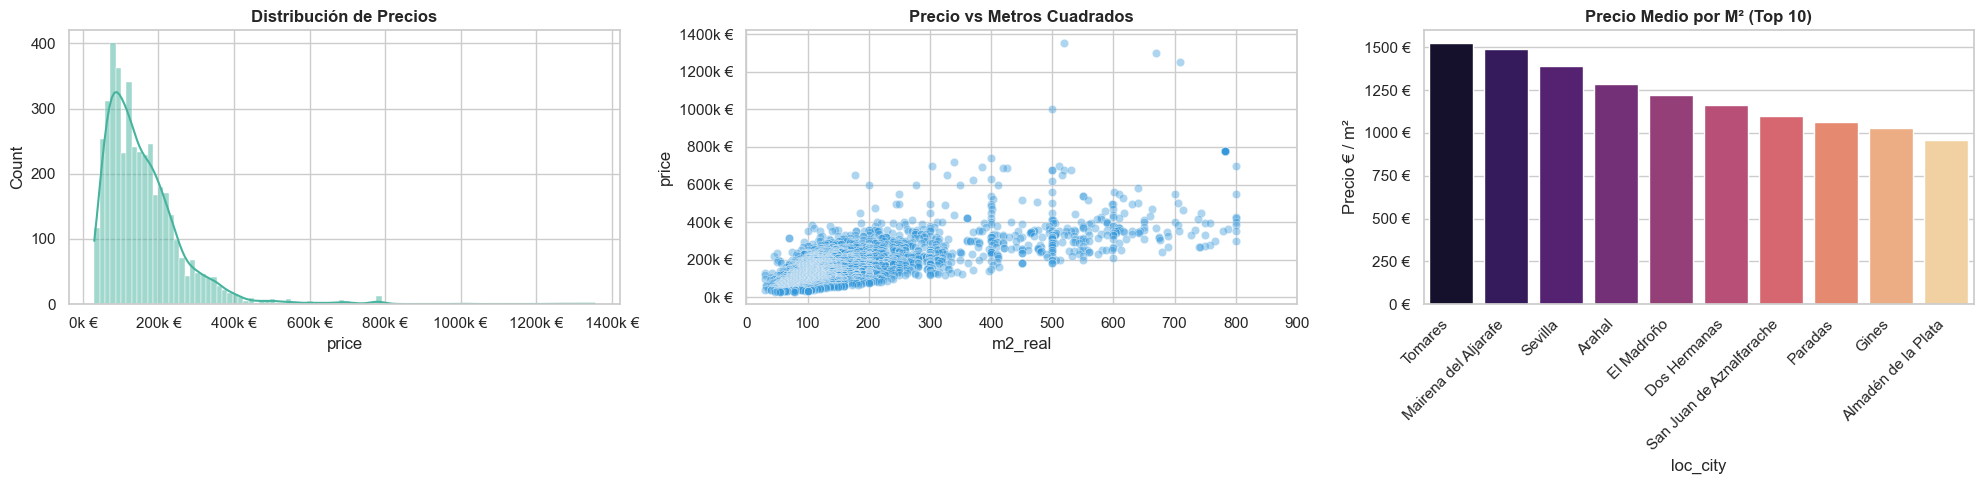

In [61]:
# PASO 5: VISUALIZACIÓN DE LOS DATOS LIMPIOS

import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo 
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. GRÁFICO IZQUIERDA: Distribución de Precios (Histograma)
sns.histplot(df_modelo['price'], kde=True, color='#45B39D', ax=axes[0])
axes[0].set_title('Distribución de Precios', fontweight='bold')
axes[0].set_xlabel('price')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k €'))

# 2. GRÁFICO CENTRO: Precio vs Metros Cuadrados (Scatter Plot)
sns.scatterplot(data=df_modelo, x='m2_real', y='price', alpha=0.4, color='#3498DB', ax=axes[1])
axes[1].set_title('Precio vs Metros Cuadrados', fontweight='bold')
axes[1].set_xlim(0, 900)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k €'))

# 3. GRÁFICO DERECHA: Precio Medio por M² (Bar Plot - Top 10)
top_10_ciudades = df_modelo.groupby('loc_city')['price_m2'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_10_ciudades.index, y=top_10_ciudades.values, palette='magma', ax=axes[2])
axes[2].set_title('Precio Medio por M² (Top 10)', fontweight='bold')
axes[2].set_ylabel('Precio € / m²')
axes[2].set_xlabel('loc_city')
axes[2].set_xticks(range(len(top_10_ciudades)))
axes[2].set_xticklabels(top_10_ciudades.index, rotation=45, ha='right')
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x)} €'))

plt.tight_layout()
plt.show()

1. Python: Preparando datos para enviar a R...
2. Python: Escribiendo el script de R...
3. Ejecutando motor de R (Rscript.exe)...
✅ ¡Gráfico de R generado con éxito!


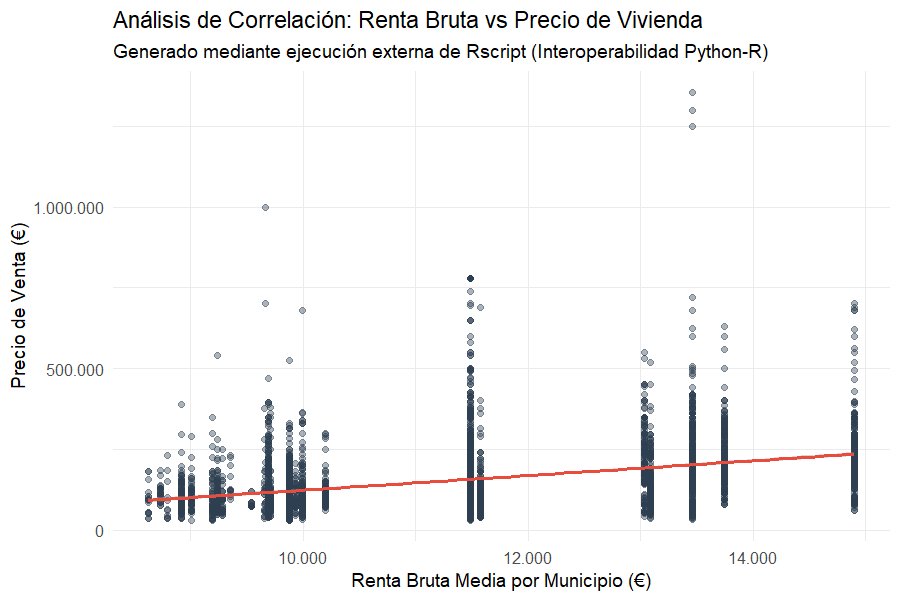

\n5. Limpiando archivos temporales...
🧹 Taller limpio. ¡Integración Python-R completada con sobresaliente!


In [62]:
import pandas as pd
import subprocess
from IPython.display import Image, display
import os

# ==============================================================================
# REQUISITO AVANZADO 3: INTEROPERABILIDAD CON R (VERSIÓN DEFINITIVA)
# ==============================================================================

print("1. Python: Preparando datos para enviar a R...")

# 1. Ya sabemos exactamente cómo se llama la columna
nombre_renta = 'renta_bruta_media'

# 2. Rutas absolutas automáticas (Para que R nunca se pierda buscando los archivos)
ruta_actual = os.getcwd()
ruta_csv = os.path.join(ruta_actual, 'datos_para_r.csv')
ruta_script = os.path.join(ruta_actual, 'script_viviendas.R')
ruta_img = os.path.join(ruta_actual, 'grafico_renta_precio.png')

# 3. Preparamos los datos temporales
df_r = df_modelo[[nombre_renta, 'price']].dropna()
df_r.columns = ['renta_bruta', 'precio_vivienda'] # Normalizamos para R
df_r.to_csv(ruta_csv, index=False)

print("2. Python: Escribiendo el script de R...")

# R necesita las barras hacia la derecha (/) en las rutas de Windows
ruta_csv_r = ruta_csv.replace('\\', '/')
ruta_img_r = ruta_img.replace('\\', '/')

codigo_r = f"""
# Evitamos que R pregunte por el servidor al instalar y congele tu Python
options(repos = c(CRAN = "http://cran.us.r-project.org"))

if (!require("ggplot2", quietly = TRUE)) install.packages("ggplot2")
if (!require("scales", quietly = TRUE)) install.packages("scales")

library(ggplot2)
library(scales)

# Leemos el archivo usando la ruta absoluta que nos pasó Python
viviendas <- read.csv('{ruta_csv_r}')

# Configuramos la imagen de salida
png('{ruta_img_r}', width=900, height=600, res=100)

# Creamos el gráfico profesional
p <- ggplot(viviendas, aes(x=renta_bruta, y=precio_vivienda)) +
  geom_point(alpha=0.4, color="#2c3e50") +
  geom_smooth(method="lm", color="#e74c3c", se=TRUE) +
  theme_minimal(base_size=14) +
  labs(
    title="Análisis de Correlación: Renta Bruta vs Precio de Vivienda",
    subtitle="Generado mediante ejecución externa de Rscript (Interoperabilidad Python-R)",
    x="Renta Bruta Media por Municipio (€)",
    y="Precio de Venta (€)"
  ) +
  scale_y_continuous(labels = comma_format(big.mark = ".", decimal.mark = ",")) +
  scale_x_continuous(labels = comma_format(big.mark = ".", decimal.mark = ","))

print(p)
invisible(dev.off())
"""

# Guardamos el script en tu disco duro temporalmente
with open(ruta_script, "w", encoding="utf-8") as f:
    f.write(codigo_r)

print("3. Ejecutando motor de R (Rscript.exe)...")

# ⚠️ ¡IMPORTANTE! Asegúrate de que esta ruta coincide con tu instalación en C:
ruta_rscript = r"C:\Program Files\R\R-4.4.2\bin\Rscript.exe"

# Verificamos si R está instalado
if not os.path.exists(ruta_rscript):
    print("⚠️ R no está instalado o la ruta no es correcta. Saltando interoperabilidad con R.")
    print("Para habilitar esta funcionalidad, instala R desde https://cran.r-project.org/")
else:
    try:
        # Ejecutamos R capturando los errores para que te los diga en español si falla
        resultado = subprocess.run([ruta_rscript, ruta_script], capture_output=True, text=True, check=True)
        print("✅ ¡Gráfico de R generado con éxito!")
        
        # 4. Mostrar resultado en Jupyter
        display(Image(filename=ruta_img))
        
        # 5. Limpieza automática
        print("\\n5. Limpiando archivos temporales...")
        os.remove(ruta_csv)
        os.remove(ruta_script)
        # os.remove(ruta_img) # Descomenta esto si no quieres conservar la imagen en la carpeta
        print("🧹 Taller limpio. ¡Integración Python-R completada con sobresaliente!")
        
    except subprocess.CalledProcessError as e:
        print(f"❌ Error interno de R al ejecutar el script:\\n{e.stderr}")
    except Exception as e:
        print(f"❌ Error inesperado: {e}")

# Limpieza si no se mostró la imagen
if os.path.exists(ruta_csv):
    os.remove(ruta_csv)
if os.path.exists(ruta_script):
    os.remove(ruta_script)

# PASO 6: GUARDADO DEL DATASET PROCESADO

In [63]:
# PASO 6: GUARDADO DEL DATASET PROCESADO

# 1. Definimos la ruta y el nombre del archivo
ruta_final = '../data/processed/viviendas_sevilla_limpio.csv'

# 2. Guardamos el DataFrame sin el índice de filas
df_modelo.to_csv(ruta_final, index=False)

print(f"✅ ¡Éxito! El dataset ha sido blindado y guardado en: {ruta_final}")
print(f"📊 Resumen final: {df_modelo.shape[0]} filas y {df_modelo.shape[1]} columnas.")

# 3. Pequeño vistazo a los tipos de datos finales antes de la IA
print("\n--- TIPOS DE DATOS LISTOS PARA EL MODELO ---")
print(df_modelo.dtypes.value_counts())

✅ ¡Éxito! El dataset ha sido blindado y guardado en: ../data/processed/viviendas_sevilla_limpio.csv
📊 Resumen final: 4247 filas y 20 columnas.

--- TIPOS DE DATOS LISTOS PARA EL MODELO ---
int64      13
string      3
float64     3
str         1
Name: count, dtype: int64
